In [ ]:
from __future__ import absolute_import, division, print_function, unicode_literals

! pip -q install git+https://www.github.com/keras-team/keras-contrib.git sklearn-crfsuite

import tensorflow as tf
import keras

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

  error: subprocess-exited-with-error
  
  × git clone --filter=blob:none --quiet https://www.github.com/keras-team/keras-contrib.git /tmp/pip-req-build-6tdigm9r did not run successfully.
  │ exit code: 128
  ╰─> [1 lines of output]
      fatal: unable to access 'https://www.github.com/keras-team/keras-contrib.git/': Could not resolve host: www.github.com
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: subprocess-exited-with-error

× git clone --filter=blob:none --quiet https://www.github.com/keras-team/keras-contrib.git /tmp/pip-req-build-6tdigm9r did not run successfully.
│ exit code: 128
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


2024-05-21 11:10:02.305903: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-21 11:10:02.306094: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-21 11:10:02.494710: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
print(tf.__version__)

2.15.0


In [ ]:
BATCH_SIZE = 64  # Number of examples used in each iteration
EPOCHS = 100  # Number of passes through entire dataset
MAX_LEN = 100  # Max length of review (in words)
EMBEDDING = 100  # Dimension of word embedding vector

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

# data = pd.read_csv("/kaggle/input/dataset-pos-pidana-baru/DatasetPos-Pidana200.csv", encoding="latin1")
data = pd.read_csv("/kaggle/input/pidana-umum-500/Dataset-Pidana500.csv", encoding="latin1")
# data = pd.read_csv("/kaggle/input/dataset-pidana-baru/Dataset-Pidana200 (1).csv")

# data['word'] = data['word'].str.lower()
data['word'] = data['word'].replace(to_replace ='\d+', value = '<\g<0>>', regex = True).replace(to_replace ='[0-9]', value = 'X', regex = True)
data = data.fillna(method="ffill")

/tmp/ipykernel_1301/2911772928.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="ffill")


In [ ]:
data

,doc,sentence,word,prev,next,tag
0,doc: 1,sentence: 000001,putusan,.,nomor,O
1,doc: 1,sentence: 000001,nomor,putusan,48,O
2,doc: 1,sentence: 000001,<XX>,nomor,/,B_VERN
3,doc: 1,sentence: 000001,/,48,pid,I_VERN
4,doc: 1,sentence: 000001,pid,/,.,I_VERN
...,...,...,...,...,...,...
3296245,doc: 500,sentence: 065700,achmad,.,junaidi,B_REGI
3296246,doc: 500,sentence: 065700,junaidi,achmad,",",I_REGI
3296247,doc: 500,sentence: 065700,",",junaidi,sh,O
3296248,doc: 500,sentence: 065700,sh,",",.,O


In [ ]:
data.groupby('tag').count()

,doc,sentence,word,prev,next
tag,,,,,
B_ARTV,1072,1072,1072,1072,1072
B_CRIA,1695,1695,1695,1695,1695
B_DEFN,6818,6818,6818,6818,6818
B_JUDP,916,916,916,916,916
B_JUG,910,910,910,910,910
B_PENA,468,468,468,468,468
B_PROS,206,206,206,206,206
B_PUNI,38,38,38,38,38
B_REGI,838,838,838,838,838


In [ ]:
words = list(set(data["word"].values))
words.append("ENDPAD")
n_words = len(words)
n_words

39500

In [ ]:
tags = list(set(data["tag"].values))
n_tags = len(tags)
n_tags

23

## Group Per Kalimat

In [ ]:
class SentenceGetter(object):

    def __init__(self, data):
        self.n_sent = 1
        self.data = data
        self.empty = False
        agg_func = lambda s: [(w, t) for w, t in zip(s["word"].values.tolist(),
                                                           s["tag"].values.tolist())]
        self.grouped = self.data.groupby("sentence").apply(agg_func)
        self.sentences = [s for s in self.grouped]

    def get_next(self):
        try:
            s = self.grouped[self.n_sent]
            self.n_sent += 1
            return s
        except:
            return None

# class DocGetter(object):

#     def __init__(self, data):
#         self.n_doc = 1
#         self.data = data
#         self.empty = False
#         agg_func = lambda s: [(w, t) for w, t in zip(s["word"].values.tolist(),
#                                                            s["tag"].values.tolist())]
#         self.grouped = self.data.groupby("doc").apply(agg_func)
#         self.docs = [s for s in self.grouped]

#     def get_next(self):
#         try:
#             d = self.grouped[self.n_doc]
#             self.n_doc += 1
#             return d
#         except:
#             return None

In [ ]:
# # getter = DocGetter(data)
# # docs = getter.docs
getter = SentenceGetter(data)
sentences = getter.sentences

/tmp/ipykernel_1301/1008250215.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  self.grouped = self.data.groupby("sentence").apply(agg_func)


In [ ]:
sentences[500]

[('demikianlah', 'O'),
 ('diputuskan', 'O'),
 ('dalam', 'O'),
 ('sidang', 'O'),
 ('permusyawaratan', 'O'),
 ('majelis', 'O'),
 ('hakim', 'O'),
 ('pengadilan', 'O'),
 ('negeri', 'O'),
 ('bangkalan', 'O'),
 (',', 'O'),
 ('pada', 'O'),
 ('hari', 'O'),
 ('kamis', 'O'),
 ('tanggal', 'O'),
 ('<XX>', 'B_TIMV'),
 ('mei', 'I_TIMV'),
 ('<XXXX>', 'I_TIMV'),
 ('oleh', 'O'),
 ('kami', 'O'),
 (',', 'O'),
 ('zainal', 'B_JUDP'),
 ('ahmad', 'I_JUDP'),
 (',', 'I_JUDP'),
 ('s', 'O'),
 ('.', 'O'),
 ('h', 'O'),
 ('.', 'O'),
 (',', 'O'),
 ('sebagai', 'O'),
 ('hakim', 'O'),
 ('ketua', 'O'),
 (',', 'O'),
 ('kadek', 'B_JUG'),
 ('dwi', 'I_JUG'),
 ('krisna', 'I_JUG'),
 ('ananda', 'I_JUG'),
 (',', 'I_JUG'),
 ('s', 'O'),
 ('.', 'O'),
 ('h', 'O'),
 ('.', 'O'),
 (',', 'O'),
 ('m', 'O'),
 ('.', 'O'),
 ('kn', 'O'),
 ('.', 'O'),
 (',', 'O'),
 ('dan', 'O'),
 ('wienda', 'O'),
 ('kresnantyo', 'O'),
 (',', 'O'),
 ('s', 'O'),
 ('.', 'O'),
 ('h', 'O'),
 ('.', 'O'),
 (',', 'O'),
 ('m', 'O'),
 ('.', 'O'),
 ('h', 'O'),
 ('.', '

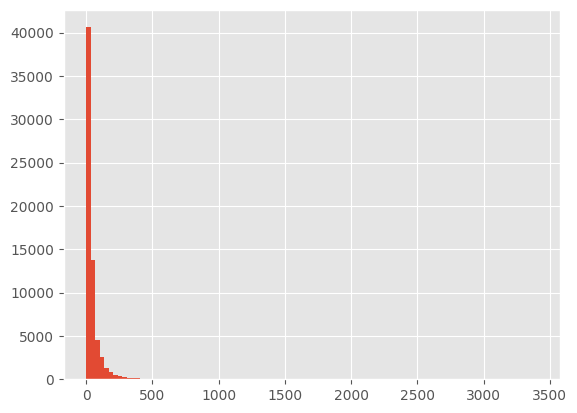

In [ ]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")

plt.hist([len(s) for s in sentences], bins=100)
plt.show()

# CBOW

In [ ]:
from gensim.models import Word2Vec
sentences_words = [[w[0] for w in s] for s in sentences]
cbow_model = Word2Vec(sentences_words, vector_size=10, window=5, min_count=1, sg=0)

In [ ]:
tag2idx = {t: i for i, t in enumerate(tags)}

idx2tag = {i: w for w, i in tag2idx.items()}

In [ ]:
def get_word_embedding(word):
    if word in cbow_model.wv:
        return cbow_model.wv[word]
    else:
        return np.zeros(cbow_model.vector_size)

In [ ]:
from tensorflow.keras.utils import pad_sequences
from keras.utils import to_categorical
X = [[get_word_embedding(w[0]) for w in s] for s in sentences]
X = pad_sequences(maxlen=MAX_LEN, sequences=X, padding="post", dtype='float32', value=np.zeros(cbow_model.vector_size))

y = [[tag2idx[w[1]] for w in s] for s in sentences]
y = pad_sequences(maxlen=MAX_LEN, sequences=y, padding="post", value=tag2idx["O"])
y = [to_categorical(i, num_classes=n_tags+1) for i in y]

In [ ]:
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, shuffle=False)
X_tr.shape, X_te.shape, np.array(y_tr).shape, np.array(y_te).shape

((52560, 100, 10), (13140, 100, 10), (52560, 100, 24), (13140, 100, 24))

In [ ]:
cbow_model.vector_size

10

In [ ]:
from keras import Model
from keras import optimizers
from keras.layers import Input, LSTM, Embedding, Dense, TimeDistributed, Dropout, Bidirectional, SpatialDropout1D, Reshape
from keras.utils import plot_model

# input = Input(shape=(MAX_LEN,)) #Asli
input = Input(shape=(MAX_LEN, cbow_model.vector_size))

# model = Embedding(input_dim=n_words, output_dim=10, input_length=5)(input)
model = Dropout(0.1)(input)
model = Bidirectional(LSTM(units=100, return_sequences=True, recurrent_dropout=0.1))(model)

out = TimeDistributed(Dense(n_tags+1, activation="softmax"))(model)  # softmax output layer

model = Model(input, out)

model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])

model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 100, 10)]         0         
                                                                 
 dropout_2 (Dropout)         (None, 100, 10)           0         
                                                                 
 bidirectional_2 (Bidirecti  (None, 100, 200)          88800     
 onal)                                                           
                                                                 
 time_distributed_2 (TimeDi  (None, 100, 24)           4824      
 stributed)                                                      
                                                                 
Total params: 93624 (365.72 KB)
Trainable params: 93624 (365.72 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
input

<KerasTensor: shape=(None, 100, 10) dtype=float32 (created by layer 'input_3')>

## Visualisasi Model

In [ ]:
! pip install pydot graphviz

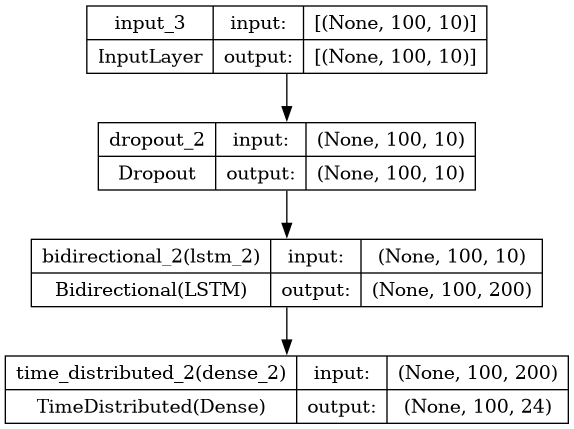

In [ ]:
from keras.utils import plot_model

plot_model(model, to_file='model_visualization.png', show_shapes=True, show_layer_names=True)

from IPython.display import Image

image_path = 'model_visualization.png'
display(Image(filename=image_path))
with open(image_path, 'rb') as img_file:
    img_data = img_file.read()

In [ ]:
history = model.fit(np.array(X_tr).astype(int),
                    np.array(y_tr).astype(int),
                    batch_size=BATCH_SIZE,
                    epochs=100,
                    validation_split=0.1,
                    verbose=1)

Epoch 1/100
740/740 [==============================] - 159s 207ms/step - loss: 0.0601 - accuracy: 0.9897 - val_loss: 0.0327 - val_accuracy: 0.9913
Epoch 2/100
740/740 [==============================] - 152s 205ms/step - loss: 0.0238 - accuracy: 0.9931 - val_loss: 0.0292 - val_accuracy: 0.9917
Epoch 3/100
740/740 [==============================] - 153s 207ms/step - loss: 0.0206 - accuracy: 0.9937 - val_loss: 0.0252 - val_accuracy: 0.9916
Epoch 4/100
740/740 [==============================] - 153s 207ms/step - loss: 0.0190 - accuracy: 0.9942 - val_loss: 0.0255 - val_accuracy: 0.9919
Epoch 5/100
740/740 [==============================] - 152s 206ms/step - loss: 0.0179 - accuracy: 0.9943 - val_loss: 0.0223 - val_accuracy: 0.9919
Epoch 6/100
740/740 [==============================] - 153s 207ms/step - loss: 0.0169 - accuracy: 0.9946 - val_loss: 0.0226 - val_accuracy: 0.9921
Epoch 7/100
740/740 [==============================] - 154s 208ms/step - loss: 0.0164 - accuracy: 0.9947 - val_loss: 0

In [ ]:
import torch

In [ ]:
path = 'model-BiLSTM-Pidana500-100Epoch.pth'
torch.save(model, path)

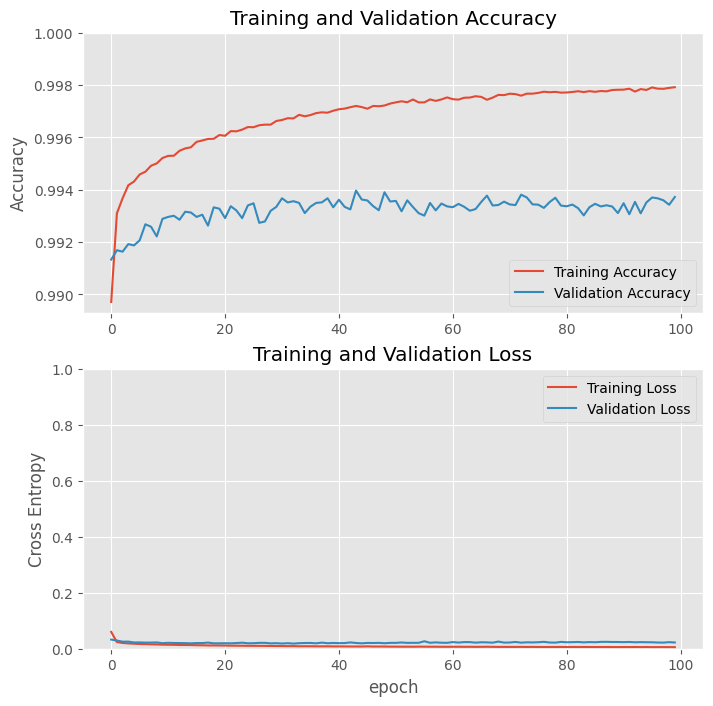

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [ ]:
eve = model.predict(X_te)

411/411 [==============================] - 14s 32ms/step


In [ ]:
y_pred = np.argmax(eve, axis=-1)
y_test_true = np.argmax(y_te, -1)

# Convert the index to tag
y_pred = [[idx2tag[i] for i in row] for row in y_pred]
y_test_true = [[idx2tag[i] for i in row] for row in y_test_true]

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

m = MultiLabelBinarizer().fit(y_test_true)
print("Precision Score: {}".format(precision_score(m.transform(y_test_true), m.transform(y_pred), average="macro")))
print("Recall Score   : {}".format(recall_score(m.transform(y_test_true), m.transform(y_pred), average="macro")))
print("F1-score Score : {}".format(f1_score(m.transform(y_test_true), m.transform(y_pred), average="macro")))

Precision Score: 0.6794669867642149
Recall Score   : 0.7227897428409784
F1-score Score : 0.6755118653965831


In [ ]:
from sklearn.metrics import classification_report
def c_report(y_pred, y_true):
  # Menggabungkan elemen-elemen array menjadi satu list
  y_pred_flat = [item for sublist in y_pred for item in sublist]
  y_true_flat = [item for sublist in y_true for item in sublist]
  report = classification_report(y_pred_flat, y_true_flat)
  return report

In [ ]:
report = c_report(y_pred, y_test_true)
print(report)

              precision    recall  f1-score   support

      B_ARTV       0.79      0.55      0.65       236
      B_CRIA       0.25      0.40      0.31       179
      B_DEFN       0.45      0.63      0.52       477
      B_JUDP       0.81      0.66      0.73       109
       B_JUG       0.37      0.89      0.53        64
      B_PENA       0.68      0.89      0.77        45
      B_PROS       0.62      0.52      0.56        46
      B_PUNI       0.25      0.12      0.16        17
      B_REGI       0.90      0.80      0.85       189
      B_TIMV       0.81      0.81      0.81        26
      B_VERN       0.99      0.79      0.88       285
      I_ARTV       0.60      0.49      0.54      1052
      I_CRIA       0.01      0.21      0.01       133
      I_DEFN       0.41      0.62      0.49      1598
      I_JUDP       0.89      0.61      0.72       205
       I_JUG       0.64      0.93      0.75       240
      I_PENA       0.62      0.81      0.70      3804
      I_PROS       0.68    

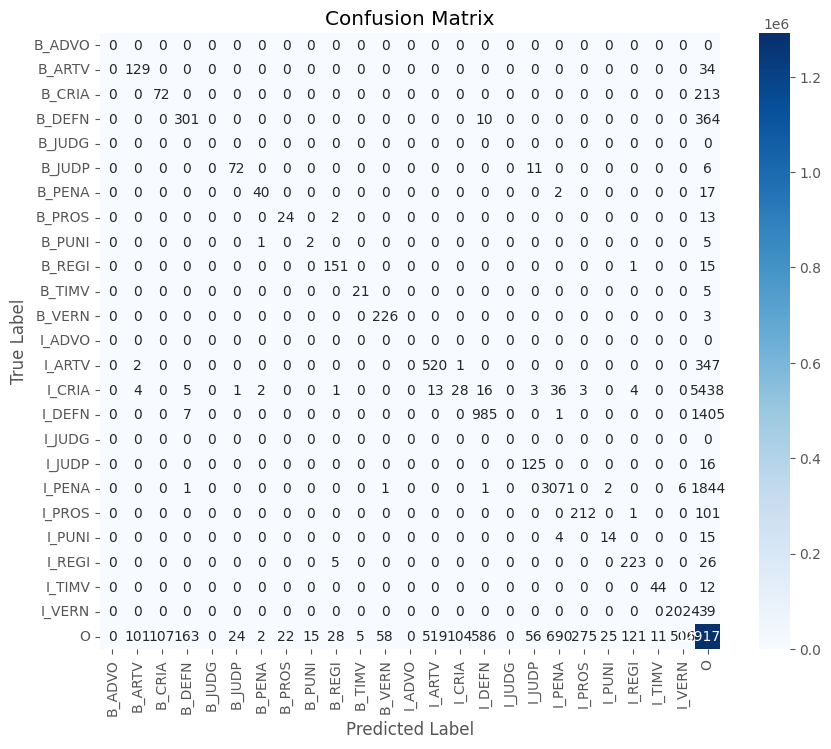

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Definisi class_names (sesuaikan dengan label yang sesuai dalam datasetmu)
class_names = ['B_ADVO', 'B_ARTV', 'B_CRIA', 'B_DEFN', 'B_JUDG', 'B_JUDP', 'B_PENA', 'B_PROS', 'B_PUNI', 'B_REGI', 'B_TIMV', 'B_VERN', 'I_ADVO', 'I_ARTV', 'I_CRIA', 'I_DEFN', 'I_JUDG', 'I_JUDP', 'I_PENA', 'I_PROS', 'I_PUNI', 'I_REGI', 'I_TIMV', 'I_VERN', 'O']

conf_mat = confusion_matrix([item for sublist in y_test_true for item in sublist],
                            [item for sublist in y_pred for item in sublist],
                            labels=class_names)
# Visualisasi confusion matrix menggunakan heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt=".0f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
def prepare_input(words, cbow_model, max_len):
    X = [[get_word_embedding(word) for word in words]]
    X = pad_sequences(maxlen=max_len, sequences=X, padding="post", dtype='float32', value=np.zeros(cbow_model.vector_size))
    return np.array(X)
def predict_single_word(model, X_new, cbow_model, max_len, idx2tag):
    y_pred = model.predict(X_new)
    y_pred = np.argmax(y_pred, axis=-1)
    predicted_tag_idx = y_pred[0][0]
    return idx2tag[predicted_tag_idx]
def predict_tags(model, words, cbow_model, max_len, idx2tag):
    X_new = prepare_input(words, cbow_model, max_len)
    y_pred = model.predict(X_new)
    y_pred = np.argmax(y_pred, axis=-1)
    predictions = [idx2tag[idx] for idx in y_pred[0]]
    return predictions

In [ ]:
new_word = 'bkl'
X_new = prepare_input(new_word, cbow_model, MAX_LEN)
predicted_tag = predict_single_word(model, X_new, cbow_model, MAX_LEN, idx2tag)
print(f"The predicted tag for '{new_word}' is '{predicted_tag}'")

1/1 [==============================] - 0s 34ms/step
The predicted tag for 'bkl' is 'O'
